In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


# ---------------------------
# Imports
# ---------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adamax
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

# ---------------------------
# Dataset paths
# ---------------------------
# dataset_path = "/content/drive/MyDrive/MRI_Data"
import kagglehub
dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

train_dir = os.path.join(dataset_path, "Training")
test_dir = os.path.join(dataset_path, "Testing")

print("Training path:", train_dir)
print("Testing path:", test_dir)

# ---------------------------
# Check folder structure
# ---------------------------
print("\nTop-level folders:")
for folder in os.listdir(dataset_path):
    print("-", folder)

print("\nTraining classes and image counts:")
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

print("\nTesting classes and image counts:")
for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

TensorFlow version: 2.20.0
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Training path: /kaggle/input/brain-tumor-mri-dataset/Training
Testing path: /kaggle/input/brain-tumor-mri-dataset/Testing

Top-level folders:
- Training
- Testing

Training classes and image counts:
pituitary : 1400
notumor : 1400
meningioma : 1400
glioma : 1400

Testing classes and image counts:
pituitary : 400
notumor : 400
meningioma : 400
glioma : 400



 VISUALISING THE DATA



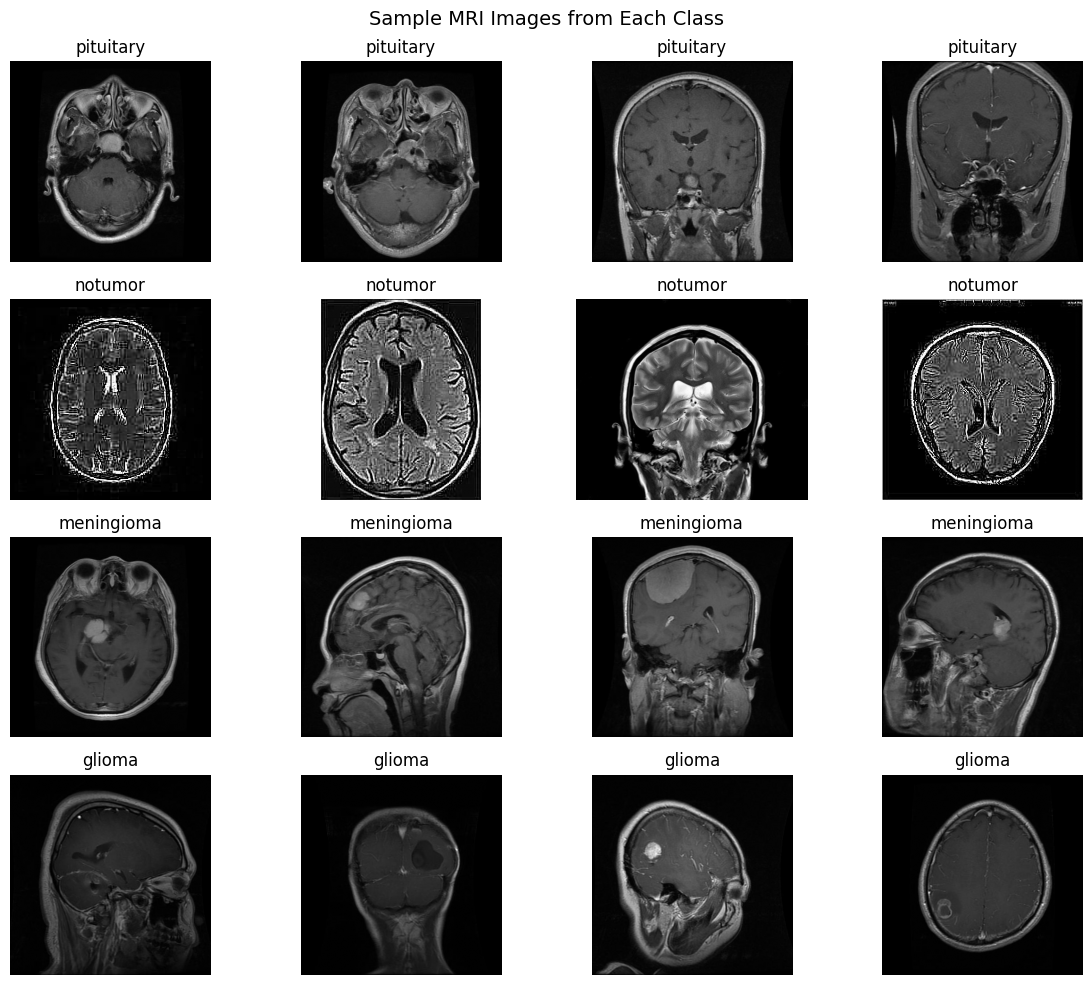

In [3]:
# ---------------------------
# Plot sample images from each class
# ---------------------------
classes = os.listdir(train_dir)
samples_per_class = 4

plt.figure(figsize=(12, 10))
plot_index = 1

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)[:samples_per_class]

    for image_name in image_names:
        image_path = os.path.join(class_path, image_name)
        img = Image.open(image_path).convert("L")

        plt.subplot(len(classes), samples_per_class, plot_index)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")
        plot_index += 1

plt.suptitle("Sample MRI Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

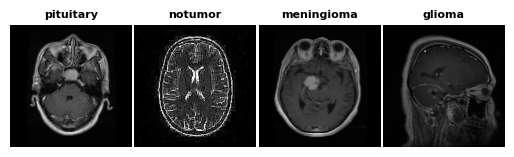

In [4]:
# ---------------------------
# Plot exactly one sample image from each class (Mini Strip)
# ---------------------------
classes = os.listdir(train_dir)

# Single row of 4 images, ultra-compact size
fig, axes = plt.subplots(1, len(classes), figsize=(5, 1.5))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    # Grab just the first image
    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)
    img = Image.open(image_path).convert("L")

    ax = axes[i]
    ax.imshow(img, cmap="gray")
    ax.axis("off")

    # Mini title above each image
    ax.set_title(class_name, fontsize=8, fontweight="bold")

plt.tight_layout(pad=0.2)
plt.show()

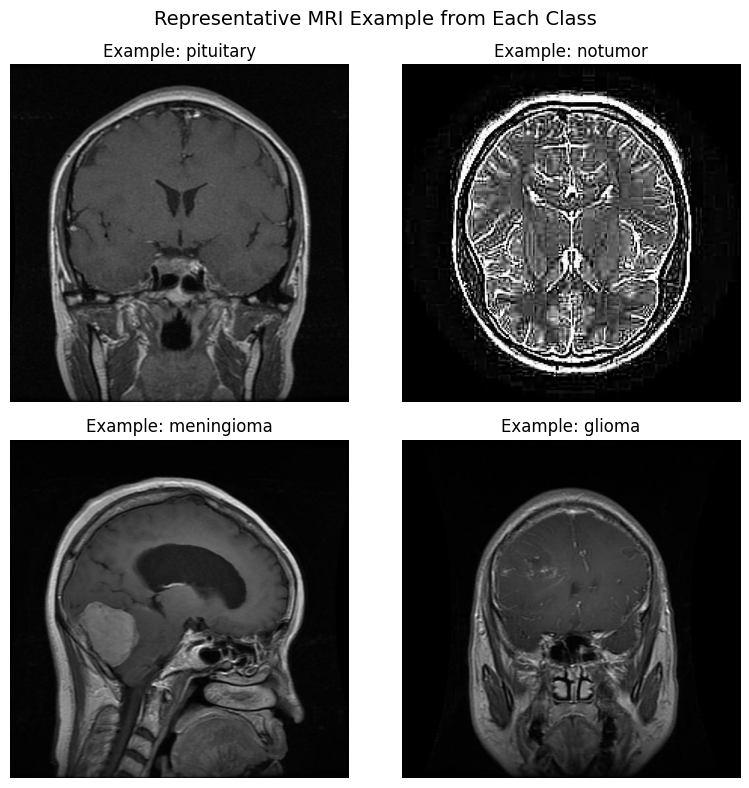

In [5]:
# ---------------------------
# Plot one representative image from each class
# ---------------------------
plt.figure(figsize=(8, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)

    # Pick one example image
    image_name = image_names[min(10, len(image_names)-1)]
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path).convert("L")

    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Example: {class_name}")
    plt.axis("off")

plt.suptitle("Representative MRI Example from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

1️⃣ Class Distribution Plot

This shows how many MRI images exist per tumour type:

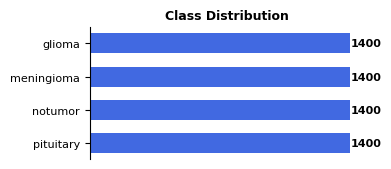

In [6]:
import os
import matplotlib.pyplot as plt

# 1. Calculate class counts
classes = os.listdir(train_dir)
counts = [len(os.listdir(os.path.join(train_dir, c))) for c in classes]

# 2. Plot compact horizontal bar chart (takes up less vertical space)
fig, ax = plt.subplots(figsize=(4, 1.8))
bars = ax.barh(classes, counts, color="royalblue", height=0.6)

# 3. Clean up styling and shrink text
ax.set_title("Class Distribution", fontsize=9, fontweight="bold")
ax.tick_params(axis="both", labelsize=8)
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.set_xticks([])  # Remove x-axis numbers to save space

# Add count labels directly onto the ends of the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2, f"{int(width)}",
            ha="left", va="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

In [7]:


print("Top-level folders:")
for folder in os.listdir(dataset_path):
    print("-", folder)

print("\nTraining classes and image counts:")
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

print("\nTesting classes and image counts:")
for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

Top-level folders:
- Training
- Testing

Training classes and image counts:
pituitary : 1400
notumor : 1400
meningioma : 1400
glioma : 1400

Testing classes and image counts:
pituitary : 400
notumor : 400
meningioma : 400
glioma : 400


In [8]:
import os
from pathlib import Path

def print_dataset_tree(dataset_root):
    root = Path(dataset_root)
    print(f"📁 {root.name}/")

    splits = sorted([d for d in root.iterdir() if d.is_dir() and not d.name.startswith('.')])
    for s_idx, split in enumerate(splits):
        is_last_split = (s_idx == len(splits) - 1)
        split_prefix = "└── " if is_last_split else "├── "
        split_pipe = "    " if is_last_split else "│   "

        print(f"{split_prefix}📁 {split.name}/")

        classes = sorted([d for d in split.iterdir() if d.is_dir()])
        for c_idx, cls in enumerate(classes):
            is_last_cls = (c_idx == len(classes) - 1)
            cls_prefix = "└── " if is_last_cls else "├── "
            cls_pipe = "    " if is_last_cls else "│   "

            files = [f for f in cls.iterdir() if f.is_file()]
            print(f"{split_pipe}{cls_prefix}📁 {cls.name}/ ({len(files)} files)")

            if files:
                print(f"{split_pipe}{cls_pipe}└── 📄 {files[0].name}")

print_dataset_tree(dataset_path)

📁 brain-tumor-mri-dataset/
├── 📁 Testing/
│   ├── 📁 glioma/ (400 files)
│   │   └── 📄 Te-gl_16.jpg
│   ├── 📁 meningioma/ (400 files)
│   │   └── 📄 Te-me_251.jpg
│   ├── 📁 notumor/ (400 files)
│   │   └── 📄 Te-no_39.jpg
│   └── 📁 pituitary/ (400 files)
│       └── 📄 Te-pi_307.jpg
└── 📁 Training/
    ├── 📁 glioma/ (1400 files)
    │   └── 📄 Tr-gl_1362.jpg
    ├── 📁 meningioma/ (1400 files)
    │   └── 📄 Tr-me_166.jpg
    ├── 📁 notumor/ (1400 files)
    │   └── 📄 Tr-no_323.jpg
    └── 📁 pituitary/ (1400 files)
        └── 📄 Tr-pi_124.jpg


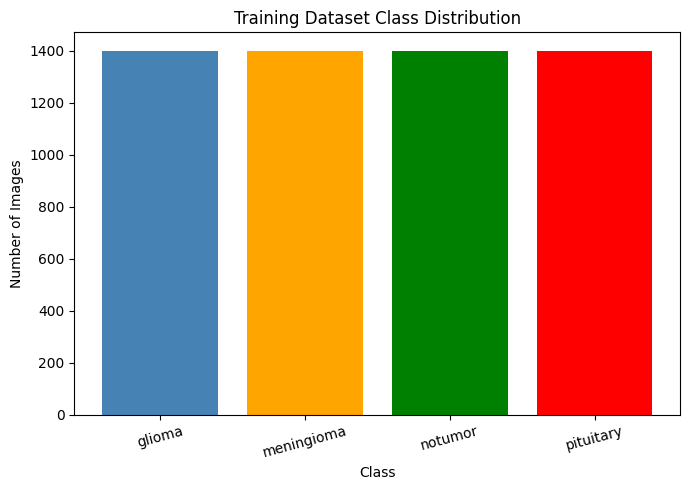

In [9]:
import os
import matplotlib.pyplot as plt

classes = sorted(os.listdir(train_dir))
class_counts = []

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    class_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(7, 5))
plt.bar(classes, class_counts, color=['steelblue', 'orange', 'green', 'red'])
plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Found 5600 validated image filenames belonging to 4 classes.


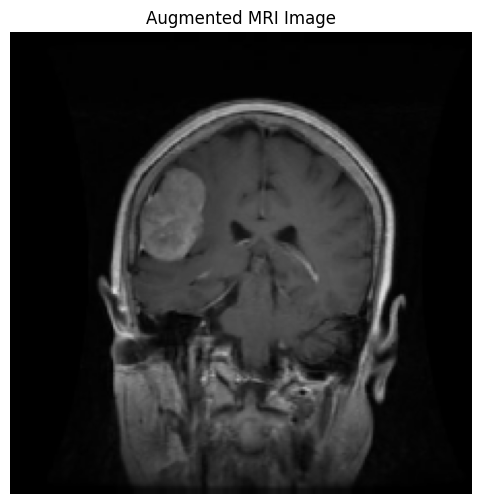

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import pandas as pd

# Create DataFrame for training images (copied from cell LdauvYrO5pZG)
train_filepaths = []
train_labels = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)

    for image_name in image_names:
        image_path = os.path.join(class_path, image_name)
        train_filepaths.append(image_path)
        train_labels.append(class_name)

train_df = pd.DataFrame({
    "File Path": train_filepaths,
    "Label": train_labels
})

aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

aug_gen = aug_datagen.flow_from_dataframe(
    train_df,
    x_col='File Path',
    y_col='Label',
    target_size=(224, 224),
    class_mode='categorical',
    color_mode='rgb',
    batch_size=1,
    shuffle=True
)

images, labels = next(aug_gen)

plt.figure(figsize=(6, 6))
plt.imshow(images[0])
plt.title("Augmented MRI Image")
plt.axis('off')
plt.show()

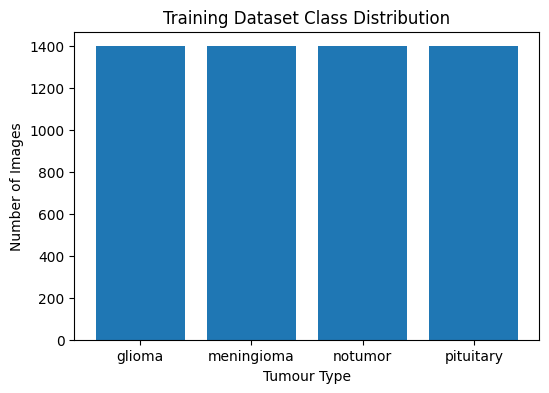

In [12]:
# ---------------------------
# Class distribution plot
# ---------------------------
class_counts = []

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    class_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(6, 4))
plt.bar(classes, class_counts)
plt.title("Training Dataset Class Distribution")
plt.xlabel("Tumour Type")
plt.ylabel("Number of Images")
plt.show()


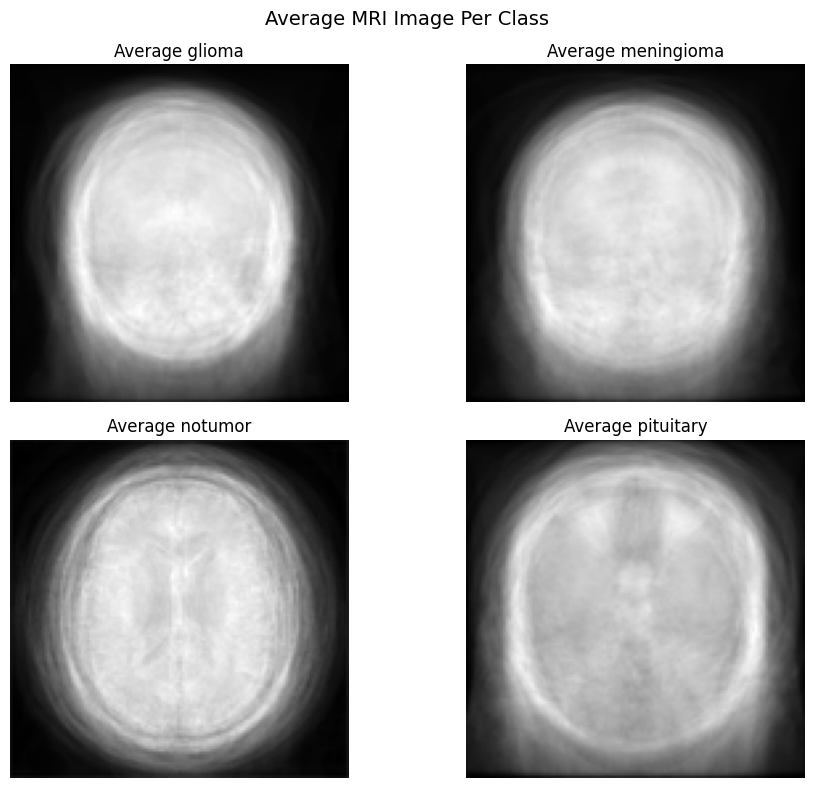

In [13]:
# ---------------------------
# Average image per class
# ---------------------------
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)

    image_stack = []

    for image_name in image_names[:200]:   # limit for speed
        image_path = os.path.join(class_path, image_name)
        img = Image.open(image_path).convert("L").resize((128, 128))
        img_array = np.array(img)
        image_stack.append(img_array)

    avg_image = np.mean(image_stack, axis=0)

    plt.subplot(2, 2, i + 1)
    plt.imshow(avg_image, cmap="gray")
    plt.title(f"Average {class_name}")
    plt.axis("off")

plt.suptitle("Average MRI Image Per Class", fontsize=14)
plt.tight_layout()
plt.show()

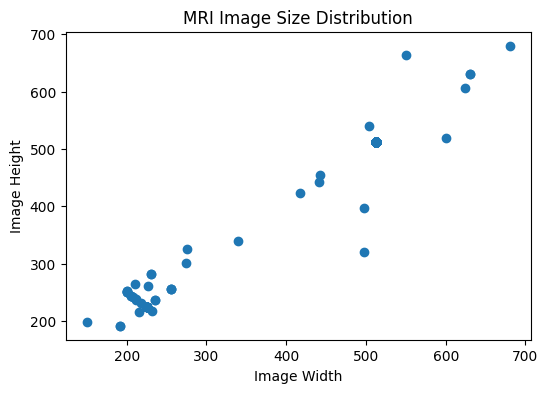

In [14]:
# ---------------------------
# Image size distribution
# ---------------------------
widths = []
heights = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)[:50]

    for image_name in image_names:
        img = Image.open(os.path.join(class_path, image_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(6, 4))
plt.scatter(widths, heights)
plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.title("MRI Image Size Distribution")
plt.show()


BUILD DATAFRAMES AND PREPROCESSING PIPELINE


In [15]:


# ---------------------------
# Create DataFrame for training images
# ---------------------------
train_filepaths = []
train_labels = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)

    for image_name in image_names:
        image_path = os.path.join(class_path, image_name)
        train_filepaths.append(image_path)
        train_labels.append(class_name)

train_df = pd.DataFrame({
    "File Path": train_filepaths,
    "Label": train_labels
})

print("\nTraining DataFrame:")
display(train_df.head())
print("Total training images:", len(train_df))

# ---------------------------
# Create DataFrame for testing images
# ---------------------------
test_filepaths = []
test_labels = []

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    image_names = os.listdir(class_path)

    for image_name in image_names:
        image_path = os.path.join(class_path, image_name)
        test_filepaths.append(image_path)
        test_labels.append(class_name)

test_all_df = pd.DataFrame({
    "File Path": test_filepaths,
    "Label": test_labels
})

print("\nTesting DataFrame:")
display(test_all_df.head())
print("Total testing images:", len(test_all_df))

# ---------------------------
# Split testing folder into validation and final test
# ---------------------------
valid_df, test_df = train_test_split(
    test_all_df,
    test_size=0.5,
    random_state=42,
    stratify=test_all_df["Label"]
)

print("\nValidation images:", len(valid_df))
print("Final test images:", len(test_df))

# ---------------------------
# ImageDataGenerator with rescaling
# ---------------------------
image_size = (224, 224)
train_batch_size = 16
test_batch_size = 8

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="File Path",
    y_col="Label",
    target_size=image_size,
    class_mode="categorical",
    color_mode="rgb",
    batch_size=train_batch_size,
    shuffle=True
)

valid_gen = test_datagen.flow_from_dataframe(
    valid_df,
    x_col="File Path",
    y_col="Label",
    target_size=image_size,
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="File Path",
    y_col="Label",
    target_size=image_size,
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

print("\nClass indices:", train_gen.class_indices)




Training DataFrame:


,File Path,Label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary


Total training images: 5600

Testing DataFrame:


,File Path,Label
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary


Total testing images: 1600

Validation images: 800
Final test images: 800
Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.

Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [18]:
print("\nCNN test evaluation:")
test_results = model.evaluate(test_gen, verbose=1)


CNN test evaluation:
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8438 - loss: 0.7330


In [20]:
# ---------------------------
# Build ANN model
# ---------------------------

ann_model = Sequential([
    Flatten(input_shape=(224, 224, 3)),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(len(train_gen.class_indices), activation="softmax")
])

ann_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ann_history = ann_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5,
    verbose=1
)

print("\nANN test evaluation:")
ann_test_results = ann_model.evaluate(test_gen, verbose=1)

comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Loss": [ann_test_results[0], test_results[0]],
    "Test Accuracy": [ann_test_results[1], test_results[1]]
})

print(comparison)




Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.4171 - loss: 2.7255 - val_accuracy: 0.3975 - val_loss: 1.3030
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4677 - loss: 1.2138 - val_accuracy: 0.5675 - val_loss: 1.1363
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.5198 - loss: 1.1062 - val_accuracy: 0.5275 - val_loss: 1.1029
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.5339 - loss: 1.0539 - val_accuracy: 0.6125 - val_loss: 1.0008
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.5586 - loss: 1.0206 - val_accuracy: 0.5825 - val_loss: 1.0476

ANN test evaluation:
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6162 - loss: 1.0342
  Model  Test Loss  Test Accuracy
0   ANN    1.03417        0.61625
1   CNN    0.88303        0.83375


In [21]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Loss": [ann_test_results[0], test_results[0]],
    "Test Accuracy": [ann_test_results[1], test_results[1]]
})

print(comparison.round(4))

  Model  Test Loss  Test Accuracy
0   ANN     1.0342         0.6162
1   CNN     0.8830         0.8338


 BASELINE CNN MODEL

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │       692,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 719,380 (2.74 MB)

 Trainable params: 719,380 (2.74 MB)

 Non-trainable params: 0 (0.00 B)


>>> Starting Baseline Model Training...
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.7107 - loss: 0.7246 - val_accuracy: 0.7325 - val_loss: 0.7703
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.8400 - loss: 0.4138 - val_accuracy: 0.7513 - val_loss: 0.8508
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.8880 - loss: 0.2985 - val_accuracy: 0.8263 - val_loss: 0.7505
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9211 - loss: 0.2149 - val_accuracy: 0.8200 - val_loss: 0.7261
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9321 - loss: 0.1789 - val_accuracy: 0.8450 - val_loss: 0.7310

>>> Evaluating Final Model Performance...

       FINAL BASELINE CNN RESULTS
| Split           |   Loss | Accuracy   |
|:----------------|-------:|:-----------|
| Training Data   | 0.1789 | 93.21%     |
| Validation Data | 0.731  | 84.50%     |
| Testing Data    | 0.7359 | 84.25%     |


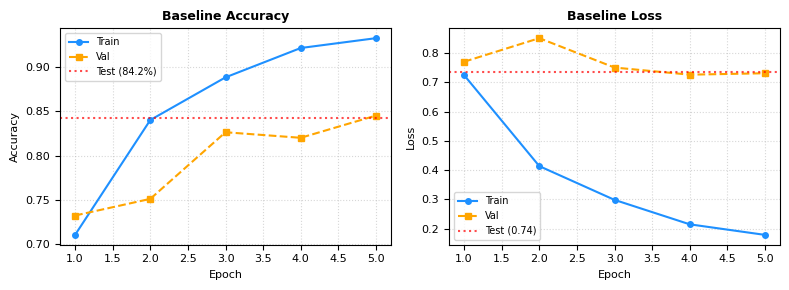

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adamax

# 1. Architecture Setup
model = Sequential([
    Conv2D(64, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(16, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])

# 2. Compile & Summary Display
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# 3. Model Training
print("\n>>> Starting Baseline Model Training...")
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5,
    verbose=1
)

# 4. Extract Final Metrics & Evaluate
print("\n>>> Evaluating Final Model Performance...")
final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

# Evaluate on test generator
test_metrics = model.evaluate(test_gen, verbose=0)
test_loss, test_acc = test_metrics[0], test_metrics[1]

# 5. Format and Print Final Scores Table
summary_df = pd.DataFrame([
    {"Split": "Training Data",   "Loss": f"{final_train_loss:.4f}", "Accuracy": f"{final_train_acc:.2%}"},
    {"Split": "Validation Data", "Loss": f"{final_val_loss:.4f}",   "Accuracy": f"{final_val_acc:.2%}"},
    {"Split": "Testing Data",    "Loss": f"{test_loss:.4f}",       "Accuracy": f"{test_acc:.2%}"}
])

print("\n" + "="*40 + "\n       FINAL BASELINE CNN RESULTS\n" + "="*40)
print(summary_df.to_markdown(index=False))

# ---------------------------------------------------------
# 6. COMPACT TRAINING & VALIDATION CURVES WITH TEST BENCHMARKS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
epochs = range(1, len(history.history['accuracy']) + 1)

# Left Subplot: Accuracy Curves
axes[0].plot(epochs, history.history['accuracy'], 'o-', color='dodgerblue', label='Train', markersize=4)
axes[0].plot(epochs, history.history['val_accuracy'], 's--', color='orange', label='Val', markersize=4)
# Add a horizontal line showing where the final test evaluation landed
axes[0].axhline(y=test_acc, color='red', linestyle=':', alpha=0.7, label=f'Test ({test_acc:.1%})')
axes[0].set_title('Baseline Accuracy', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=8)

# Right Subplot: Loss Curves
axes[1].plot(epochs, history.history['loss'], 'o-', color='dodgerblue', label='Train', markersize=4)
axes[1].plot(epochs, history.history['val_loss'], 's--', color='orange', label='Val', markersize=4)
# Add a horizontal line showing where the final test loss landed
axes[1].axhline(y=test_loss, color='red', linestyle=':', alpha=0.7, label=f'Test ({test_loss:.2f})')
axes[1].set_title('Baseline Loss', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=8)

# Standardize small fonts, grids, and clean legends
for ax in axes:
    ax.set_xlabel('Epoch', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.show()

improved CNN

In [23]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adamax

# 1. Improved Architecture Setup (Typically includes BatchNormalization/Dropout)
improved_model = Sequential([
    Conv2D(64, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(16, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),  # Helps prevent overfitting
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])

# 2. Compile & Summary Display
improved_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
improved_model.summary()

# 3. Improved Model Training
print("\n>>> Starting Improved Model Training...")
improved_history = improved_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5,
    verbose=1
)

# 4. Extract Final Metrics & Evaluate
print("\n>>> Evaluating Improved Model Performance...")
final_train_loss = improved_history.history['loss'][-1]
final_train_acc = improved_history.history['accuracy'][-1]
final_val_loss = improved_history.history['val_loss'][-1]
final_val_acc = improved_history.history['val_accuracy'][-1]

# Evaluate on test generator
improved_test_results = improved_model.evaluate(test_gen, verbose=0)
test_loss, test_acc = improved_test_results[0], improved_test_results[1]

# 5. Format and Print Final Scores Table
summary_df = pd.DataFrame([
    {"Split": "Training Data",   "Loss": f"{final_train_loss:.4f}", "Accuracy": f"{final_train_acc:.2%}"},
    {"Split": "Validation Data", "Loss": f"{final_val_loss:.4f}",   "Accuracy": f"{final_val_acc:.2%}"},
    {"Split": "Testing Data",    "Loss": f"{test_loss:.4f}",       "Accuracy": f"{test_acc:.2%}"}
])

print("\n" + "="*40 + "\n       FINAL IMPROVED CNN RESULTS\n" + "="*40)
print(summary_df.to_markdown(index=False))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       692,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 719,828 (2.75 MB)

 Trainable params: 719,604 (2.75 MB)

 Non-trainable params: 224 (896.00 B)


>>> Starting Improved Model Training...
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.7041 - loss: 0.7513 - val_accuracy: 0.4563 - val_loss: 1.5826
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.8229 - loss: 0.4570 - val_accuracy: 0.7113 - val_loss: 0.7754
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.8664 - loss: 0.3533 - val_accuracy: 0.7775 - val_loss: 0.8475
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.8930 - loss: 0.2866 - val_accuracy: 0.8350 - val_loss: 0.7126
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9187 - loss: 0.2206 - val_accuracy: 0.8313 - val_loss: 0.9234

>>> Evaluating Improved Model Performance...

       FINAL IMPROVED CNN RESULTS
| Split           |   Loss | Accuracy   |
|:----------------|-------:|:-----------|
| Training Data   | 0.2206 | 91.87%     |
| Validation Data | 0.9234 | 83.13%     |
| Testing Data    | 1.0345 | 82.50%     |


Comparison block baseline CNN vs improved CNN


| Model        |   Test Loss | Test Accuracy   |
|:-------------|------------:|:----------------|
| Baseline CNN |      0.883  | 83.38%          |
| Improved CNN |      1.0345 | 82.50%          |


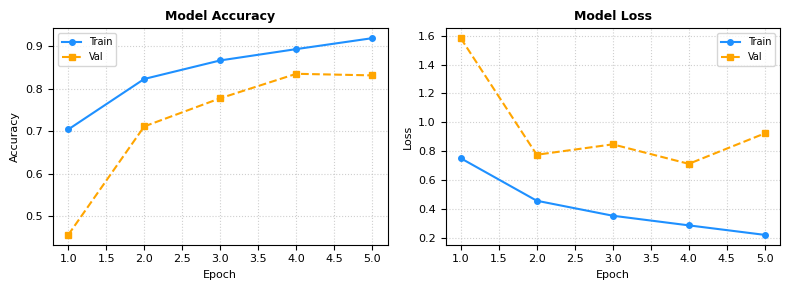

In [24]:
import pandas as pd

# 1. Consolidate Results
results = {
    "Baseline CNN": test_results,
    "Improved CNN": improved_test_results
}
if "aug_test_results" in globals():
    results["Augmented CNN"] = aug_test_results

# 2. Build and Format DataFrame
df = pd.DataFrame([
    {
        "Model": name,
        "Test Loss": f"{metrics[0]:.4f}",
        "Test Accuracy": f"{metrics[1]:.2%}"
    }
    for name, metrics in results.items()
])

# 3. Print as an elegant Markdown Table
print(df.to_markdown(index=False))
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Plot Compact Training Curves (Loss & Accuracy)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
epochs = range(1, len(improved_history.history['accuracy']) + 1)

# 1. Accuracy Subplot
axes[0].plot(epochs, improved_history.history['accuracy'], 'o-', color='dodgerblue', label='Train', markersize=4)
axes[0].plot(epochs, improved_history.history['val_accuracy'], 's--', color='orange', label='Val', markersize=4)
axes[0].set_title('Model Accuracy', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=8)

# 2. Loss Subplot
axes[1].plot(epochs, improved_history.history['loss'], 'o-', color='dodgerblue', label='Train', markersize=4)
axes[1].plot(epochs, improved_history.history['val_loss'], 's--', color='orange', label='Val', markersize=4)
axes[1].set_title('Model Loss', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=8)

# Global styling adjustments
for ax in axes:
    ax.set_xlabel('Epoch', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.show()

ResNet50

In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D

resnet_train_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)
resnet_test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

resnet_train_gen = resnet_train_datagen.flow_from_dataframe(
    train_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=train_batch_size,
    shuffle=True
)

resnet_valid_gen = resnet_test_datagen.flow_from_dataframe(
    valid_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

resnet_test_gen = resnet_test_datagen.flow_from_dataframe(
    test_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

resnet_base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
resnet_base.trainable = False

resnet_model = Sequential([
    resnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(len(train_gen.class_indices), activation="softmax")
])

resnet_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_history = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_valid_gen,
    epochs=5,
    verbose=1
)

resnet_test_results = resnet_model.evaluate(resnet_test_gen, verbose=1)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.8105 - loss: 0.5110 - val_accuracy: 0.8100 - val_loss: 0.5834
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.8877 - loss: 0.3089 - val_accuracy: 0.8687 - val_loss: 0.4600
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9123 - loss: 0.2421 - val_accuracy: 0.8662 - val_loss: 0.4755
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9286 - loss: 0.2027 - val_accuracy: 0.8675 - val_loss: 0.5273
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9327 - loss: 0.1854 - val_accuracy: 0.8788 - val_loss: 0.4956
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8800 - loss: 0.5168


MobileNetV2 model


In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

mobile_train_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
mobile_test_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

mobile_train_gen = mobile_train_datagen.flow_from_dataframe(
    train_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=train_batch_size,
    shuffle=True
)

mobile_valid_gen = mobile_test_datagen.flow_from_dataframe(
    valid_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

mobile_test_gen = mobile_test_datagen.flow_from_dataframe(
    test_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

mobile_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
mobile_base.trainable = False

mobile_model = Sequential([
    mobile_base,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(len(train_gen.class_indices), activation="softmax")
])

mobile_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobile_history = mobile_model.fit(
    mobile_train_gen,
    validation_data=mobile_valid_gen,
    epochs=5,
    verbose=1
)

mobile_test_results = mobile_model.evaluate(mobile_test_gen, verbose=1)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 51s 91ms/step - accuracy: 0.8107 - loss: 0.5194 - val_accuracy: 0.8288 - val_loss: 0.5225
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.8813 - loss: 0.3265 - val_accuracy: 0.8375 - val_loss: 0.5120
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9023 - loss: 0.2621 - val_accuracy: 0.8587 - val_loss: 0.4506
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.9173 - loss: 0.2203 - val_accuracy: 0.8575 - val_loss: 0.4555
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9295 - loss: 0.1923 - val_accuracy: 0.8800 - val_loss: 0.4558
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8825 - loss: 0.5095


EfficientNetB0 code

In [27]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D

eff_train_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)
eff_test_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)

eff_train_gen = eff_train_datagen.flow_from_dataframe(
    train_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=train_batch_size,
    shuffle=True
)

eff_valid_gen = eff_test_datagen.flow_from_dataframe(
    valid_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

eff_test_gen = eff_test_datagen.flow_from_dataframe(
    test_df,
    x_col="File Path",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    color_mode="rgb",
    batch_size=test_batch_size,
    shuffle=False
)

eff_base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
eff_base.trainable = False

eff_model = Sequential([
    eff_base,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(len(train_gen.class_indices), activation="softmax")
])

eff_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

eff_history = eff_model.fit(
    eff_train_gen,
    validation_data=eff_valid_gen,
    epochs=5,
    verbose=1
)

eff_test_results = eff_model.evaluate(eff_test_gen, verbose=1)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 57s 88ms/step - accuracy: 0.8009 - loss: 0.5283 - val_accuracy: 0.8138 - val_loss: 0.5203
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8800 - loss: 0.3434 - val_accuracy: 0.8413 - val_loss: 0.4570
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.8961 - loss: 0.2912 - val_accuracy: 0.8675 - val_loss: 0.4226
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9055 - loss: 0.2603 - val_accuracy: 0.8763 - val_loss: 0.4179
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9196 - loss: 0.2260 - val_accuracy: 0.8838 - val_loss: 0.4148
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8775 - loss: 0.4000


Compute precision, recall, F1 using sklearn,Get predictions and true labels for all three models,Compute precision, recall, F1 using sklearn

In [28]:
# ResNet50 predictions
resnet_pred_probs = resnet_model.predict(resnet_test_gen)
resnet_pred_labels = np.argmax(resnet_pred_probs, axis=1)
resnet_true_labels = resnet_test_gen.classes

# MobileNetV2 predictions
mobile_pred_probs = mobile_model.predict(mobile_test_gen)
mobile_pred_labels = np.argmax(mobile_pred_probs, axis=1)
mobile_true_labels = mobile_test_gen.classes

# EfficientNetB0 predictions
eff_pred_probs = eff_model.predict(eff_test_gen)
eff_pred_labels = np.argmax(eff_pred_probs, axis=1)
eff_true_labels = eff_test_gen.classes

from sklearn.metrics import precision_score, recall_score, f1_score

# ResNet50 metrics
resnet_precision = precision_score(resnet_true_labels, resnet_pred_labels, average="weighted")
resnet_recall = recall_score(resnet_true_labels, resnet_pred_labels, average="weighted")
resnet_f1 = f1_score(resnet_true_labels, resnet_pred_labels, average="weighted")

# MobileNetV2 metrics
mobile_precision = precision_score(mobile_true_labels, mobile_pred_labels, average="weighted")
mobile_recall = recall_score(mobile_true_labels, mobile_pred_labels, average="weighted")
mobile_f1 = f1_score(mobile_true_labels, mobile_pred_labels, average="weighted")

# EfficientNetB0 metrics
eff_precision = precision_score(eff_true_labels, eff_pred_labels, average="weighted")
eff_recall = recall_score(eff_true_labels, eff_pred_labels, average="weighted")
eff_f1 = f1_score(eff_true_labels, eff_pred_labels, average="weighted")

# Baseline CNN
baseline_pred_labels = np.argmax(model.predict(test_gen), axis=1)
baseline_true_labels = test_gen.classes
baseline_precision = precision_score(baseline_true_labels, baseline_pred_labels, average="weighted")
baseline_recall = recall_score(baseline_true_labels, baseline_pred_labels, average="weighted")
baseline_f1 = f1_score(baseline_true_labels, baseline_pred_labels, average="weighted")

# Improved CNN
improved_pred_labels = np.argmax(improved_model.predict(test_gen), axis=1)
improved_true_labels = test_gen.classes
improved_precision = precision_score(improved_true_labels, improved_pred_labels, average="weighted")
improved_recall = recall_score(improved_true_labels, improved_pred_labels, average="weighted")
improved_f1 = f1_score(improved_true_labels, improved_pred_labels, average="weighted")

comparison = pd.DataFrame({
    "Model": ["ResNet50", "MobileNetV2", "EfficientNetB0"],
    "Test Loss": [resnet_test_results[0], mobile_test_results[0], eff_test_results[0]],
    "Test Accuracy": [resnet_test_results[1], mobile_test_results[1], eff_test_results[1]],
    "Precision": [resnet_precision, mobile_precision, eff_precision],
    "Recall": [resnet_recall, mobile_recall, eff_recall],
    "F1-score": [resnet_f1, mobile_f1, eff_f1]
})

print(comparison.round(4))

100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
            Model  Test Loss  Test Accuracy  Precision  Recall  F1-score
0        ResNet50     0.5168         0.8800     0.8974  0.8800    0.8785
1     MobileNetV2     0.5095         0.8825     0.8932  0.8825    0.8797
2  EfficientNetB0     0.4000         0.8775     0.8826  0.8775    0.8733


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Full comparison (5 models):
            Model  Test Loss  Test Accuracy  Precision  Recall  F1-score
0    Baseline CNN     0.8830         0.8338     0.8440  0.8425    0.8395
1    Improved CNN     1.0345         0.8250     0.8547  0.8250    0.8245
2        ResNet50     0.5168         0.8800     0.8974  0.8800    0.8785
3     MobileNetV2     0.5095         0.8825     0.8932  0.8825    0.8797
4  EfficientNetB0     0.4000         0.8775     0.8826  0.8775    0.8733


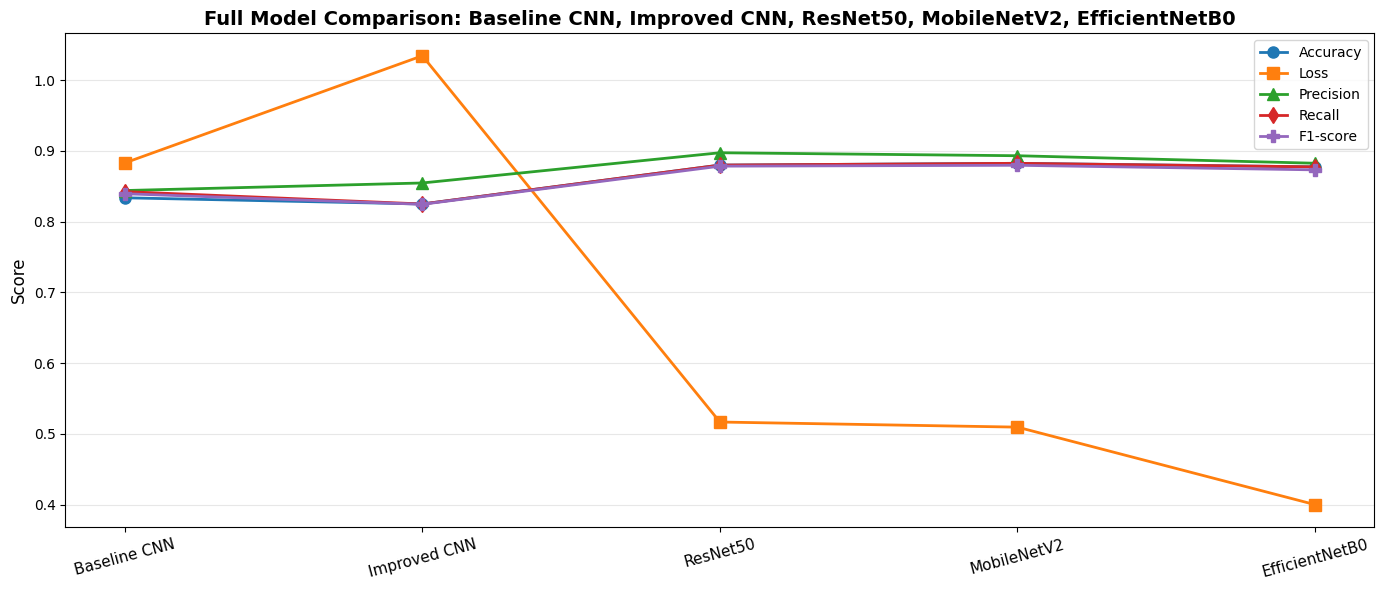

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score


# ---------------------------
# 1) Build 5-model comparison table
# ---------------------------

# Compute metrics for each model if not already done
baseline_pred_labels = np.argmax(model.predict(test_gen), axis=1)
baseline_true_labels = test_gen.classes
baseline_precision = precision_score(baseline_true_labels, baseline_pred_labels, average="weighted")
baseline_recall = recall_score(baseline_true_labels, baseline_pred_labels, average="weighted")
baseline_f1 = f1_score(baseline_true_labels, baseline_pred_labels, average="weighted")

improved_pred_labels = np.argmax(improved_model.predict(test_gen), axis=1)
improved_true_labels = test_gen.classes
improved_precision = precision_score(improved_true_labels, improved_pred_labels, average="weighted")
improved_recall = recall_score(improved_true_labels, improved_pred_labels, average="weighted")
improved_f1 = f1_score(improved_true_labels, improved_pred_labels, average="weighted")

# Pretrained models (assuming these are already computed)
# resnet_precision, resnet_recall, resnet_f1
# mobile_precision, mobile_recall, mobile_f1
# eff_precision, eff_recall, eff_f1

full_comparison = pd.DataFrame({
    "Model": ["Baseline CNN", "Improved CNN", "ResNet50", "MobileNetV2", "EfficientNetB0"],
    "Test Loss": [
        test_results[0],
        improved_test_results[0],
        resnet_test_results[0],
        mobile_test_results[0],
        eff_test_results[0]
    ],
    "Test Accuracy": [
        test_results[1],
        improved_test_results[1],
        resnet_test_results[1],
        mobile_test_results[1],
        eff_test_results[1]
    ],
    "Precision": [baseline_precision, improved_precision, resnet_precision, mobile_precision, eff_precision],
    "Recall": [baseline_recall, improved_recall, resnet_recall, mobile_recall, eff_recall],
    "F1-score": [baseline_f1, improved_f1, resnet_f1, mobile_f1, eff_f1]
})

print("Full comparison (5 models):")
print(full_comparison.round(4))


# ---------------------------
# 2) Single XY chart with all 5 models
# ---------------------------

x_full = np.arange(len(full_comparison))

plt.figure(figsize=(14, 6))

plt.plot(x_full, full_comparison["Test Accuracy"], marker="o", label="Accuracy", linewidth=2, markersize=8)
plt.plot(x_full, full_comparison["Test Loss"], marker="s", label="Loss", linewidth=2, markersize=8)
plt.plot(x_full, full_comparison["Precision"], marker="^", label="Precision", linewidth=2, markersize=8)
plt.plot(x_full, full_comparison["Recall"], marker="d", label="Recall", linewidth=2, markersize=8)
plt.plot(x_full, full_comparison["F1-score"], marker="P", label="F1-score", linewidth=2, markersize=8)

plt.xticks(x_full, full_comparison["Model"], rotation=15, fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.title(
    "Full Model Comparison: Baseline CNN, Improved CNN, ResNet50, MobileNetV2, EfficientNetB0",
    fontsize=14,
    fontweight="bold"
)
plt.legend(fontsize=10, loc="best")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

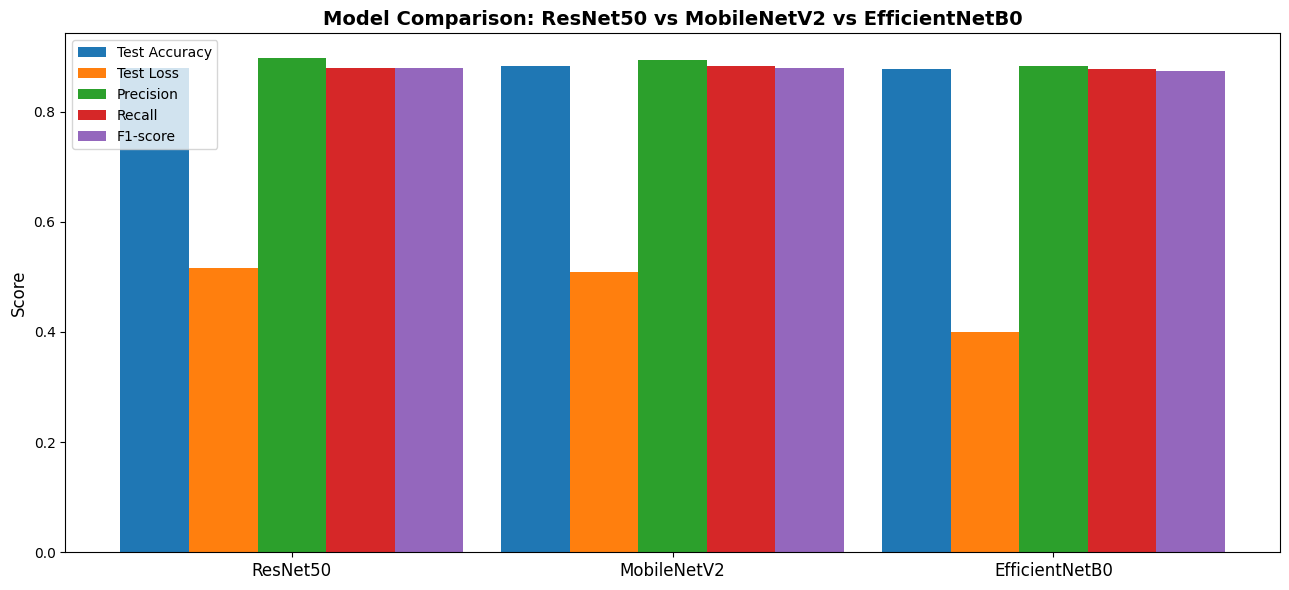

In [30]:



import matplotlib.pyplot as plt
import numpy as np

comparison_plot = comparison.set_index("Model")

metrics = ["Test Accuracy", "Test Loss", "Precision", "Recall", "F1-score"]

x = np.arange(len(comparison_plot.index))
width = 0.18

plt.figure(figsize=(13, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + i * width, comparison_plot[metric], width, label=metric)

plt.xticks(x + width * 2, comparison_plot.index, fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title(
    "Model Comparison: ResNet50 vs MobileNetV2 vs EfficientNetB0",
    fontsize=14,
    fontweight="bold"
)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Make sure you have this table first
comparison = pd.DataFrame({
    "Model": ["ResNet50", "MobileNetV2", "EfficientNetB0"],
    "Test Loss": [resnet_test_results[0], mobile_test_results[0], eff_test_results[0]],
    "Test Accuracy": [resnet_test_results[1], mobile_test_results[1], eff_test_results[1]],
    "Precision": [resnet_precision, mobile_precision, eff_precision],
    "Recall": [resnet_recall, mobile_recall, eff_recall],
    "F1-score": [resnet_f1, mobile_f1, eff_f1]
})

models = comparison["Model"]
x = np.arange(len(models))

plt.figure(figsize=(12, 6))

plt.plot(x, comparison["Test Accuracy"], marker="o", label="Accuracy", linewidth=2)
plt.plot(x, comparison["Test Loss"], marker="s", label="Loss", linewidth=2)
plt.plot(x, comparison["Precision"], marker="^", label="Precision", linewidth=2)
plt.plot(x, comparison["Recall"], marker="d", label="Recall", linewidth=2)
plt.plot(x, comparison["F1-score"], marker="P", label="F1-score", linewidth=2)

plt.xticks(x, models, fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title(
    "Model Comparison: Accuracy, Loss, Precision, Recall, F1-score",
    fontsize=14,
    fontweight="bold"
)
plt.legend(fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

confusion matrix of best (RestNet and EfficientNetB0)

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
ResNet50 Classification Report
              precision    recall  f1-score   support

      glioma       0.96      0.67      0.79       200
  meningioma       0.73      0.94      0.82       200
     notumor       0.92      0.98      0.95       200
   pituitary       0.98      0.93      0.95       200

    accuracy                           0.88       800
   macro avg       0.90      0.88      0.88       800
weighted avg       0.90      0.88      0.88       800


EfficientNetB0 Classification Report
              precision    recall  f1-score   support

      glioma       0.92      0.67      0.77       200
  meningioma       0.78      0.86      0.82       200
     notumor       0.88      0.99      0.93       200
   pituitary       0.95      0.99      0.97       200

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.87       800
weighted avg       0.88      0.8

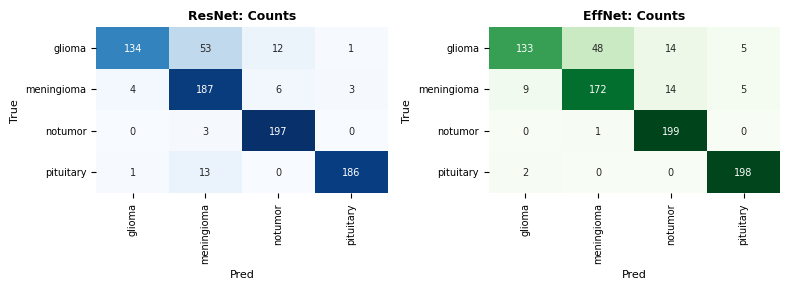

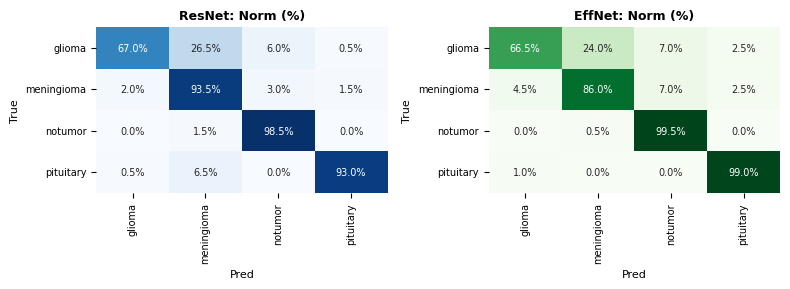

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import pandas as pd
import seaborn as sns # Added seaborn for heatmap

# ---------------------------
# Get predictions and true labels for both models
# ---------------------------

# ResNet50
resnet_pred_probs = resnet_model.predict(resnet_test_gen)
resnet_pred_labels = np.argmax(resnet_pred_probs, axis=1)
resnet_true_labels = resnet_test_gen.classes

# EfficientNetB0
eff_pred_probs = eff_model.predict(eff_test_gen)
eff_pred_labels = np.argmax(eff_pred_probs, axis=1)
eff_true_labels = eff_test_gen.classes

# Class names
class_names = list(resnet_test_gen.class_indices.keys())


# ---------------------------
# 1) Classification reports (clean text)
# ---------------------------

print("=" * 60)
print("ResNet50 Classification Report")
print("=" * 60)
resnet_report = classification_report(
    resnet_true_labels, resnet_pred_labels,
    target_names=class_names,
    output_dict=True
)
print(classification_report(resnet_true_labels, resnet_pred_labels, target_names=class_names))

print("\n" + "=" * 60)
print("EfficientNetB0 Classification Report")
print("=" * 60)
eff_report = classification_report(
    eff_true_labels, eff_pred_labels,
    target_names=class_names,
    output_dict=True
)
print(classification_report(eff_true_labels, eff_pred_labels, target_names=class_names))


# ---------------------------
# 2) Convert classification reports to nicer tables
# ---------------------------

resnet_df = pd.DataFrame(resnet_report).transpose()
eff_df = pd.DataFrame(eff_report).transpose()

print("\nResNet50 metrics table:")
print(resnet_df.round(3))

print("\nEfficientNetB0 metrics table:")
print(eff_df.round(3))


# ---------------------------
# 3) Confusion matrices with better formatting
# 3. MINI PLOTTING (Side-by-Side)
def plot_mini(cm1, cm2, title, is_norm=False):
    fig, axes = plt.subplots(1, 2, figsize=(8, 3)) # Very small size
    fmt = ".1%" if is_norm else "d"

    # ResNet Heatmap
    sns.heatmap(cm1, annot=True, fmt=fmt, cmap="Blues", ax=axes[0], cbar=False,
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
    axes[0].set_title(f"ResNet: {title}", fontsize=9, fontweight="bold")

    # EfficientNet Heatmap
    sns.heatmap(cm2, annot=True, fmt=fmt, cmap="Greens", ax=axes[1], cbar=False,
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
    axes[1].set_title(f"EffNet: {title}", fontsize=9, fontweight="bold")

    for ax in axes:
        ax.tick_params(labelsize=7)
        ax.set_xlabel("Pred", fontsize=8)
        ax.set_ylabel("True", fontsize=8)

    plt.tight_layout()
    plt.show()

# Calculate and Plot
r_cm = confusion_matrix(resnet_true_labels, resnet_pred_labels)
e_cm = confusion_matrix(eff_true_labels, eff_pred_labels)
r_cm_n = r_cm.astype('float') / r_cm.sum(axis=1, keepdims=True)
e_cm_n = e_cm.astype('float') / e_cm.sum(axis=1, keepdims=True)

plot_mini(r_cm, e_cm, "Counts")
plot_mini(r_cm_n, e_cm_n, "Norm (%)", is_norm=True)

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


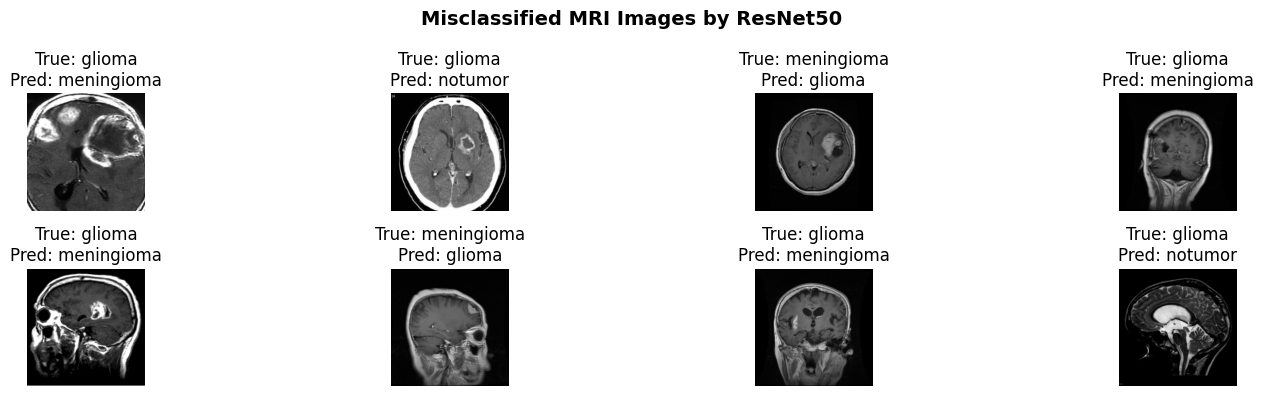

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


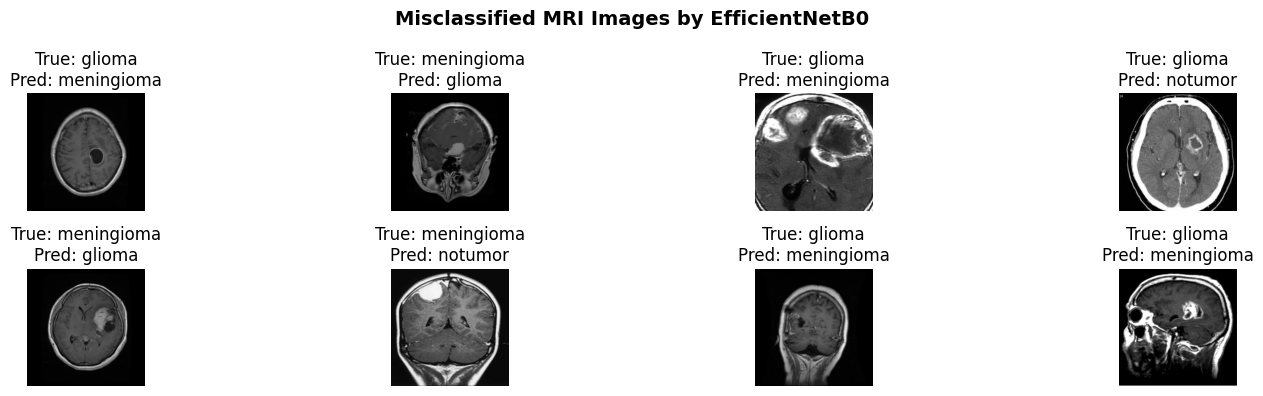

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------
# Get ResNet50 predictions and find misclassifications
# ---------------------------

resnet_pred_probs = resnet_model.predict(resnet_test_gen)
resnet_pred_labels = np.argmax(resnet_pred_probs, axis=1)
resnet_true_labels = resnet_test_gen.classes
class_names = list(resnet_test_gen.class_indices.keys())

# Find indices where prediction != true label
misclass_indices = np.where(resnet_pred_labels != resnet_true_labels)[0]

# Take first 8 misclassified images
num_samples = min(8, len(misclass_indices))
misclass_indices_show = misclass_indices[:num_samples]

# ---------------------------
# Display misclassified images with true and predicted labels
# ---------------------------

plt.figure(figsize=(16, 4))

for i, idx in enumerate(misclass_indices_show):
    # Get file path from test_df
    file_path = test_df.iloc[idx]["File Path"]
    true_label = class_names[resnet_true_labels[idx]]
    pred_label = class_names[resnet_pred_labels[idx]]

    # Load and display image
    img = Image.open(file_path).convert("L")
    img = img.resize((224, 224))

    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
    plt.axis("off")

plt.suptitle("Misclassified MRI Images by ResNet50", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# ---------------------------
# Do the same for EfficientNetB0 (optional)
# ---------------------------

eff_pred_probs = eff_model.predict(eff_test_gen)
eff_pred_labels = np.argmax(eff_pred_probs, axis=1)
eff_true_labels = eff_test_gen.classes

misclass_indices_eff = np.where(eff_pred_labels != eff_true_labels)[0]
misclass_indices_eff_show = misclass_indices_eff[:num_samples]

plt.figure(figsize=(16, 4))

for i, idx in enumerate(misclass_indices_eff_show):
    file_path = test_df.iloc[idx]["File Path"]
    true_label = class_names[eff_true_labels[idx]]
    pred_label = class_names[eff_pred_labels[idx]]

    img = Image.open(file_path).convert("L")
    img = img.resize((224, 224))

    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
    plt.axis("off")

plt.suptitle("Misclassified MRI Images by EfficientNetB0", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


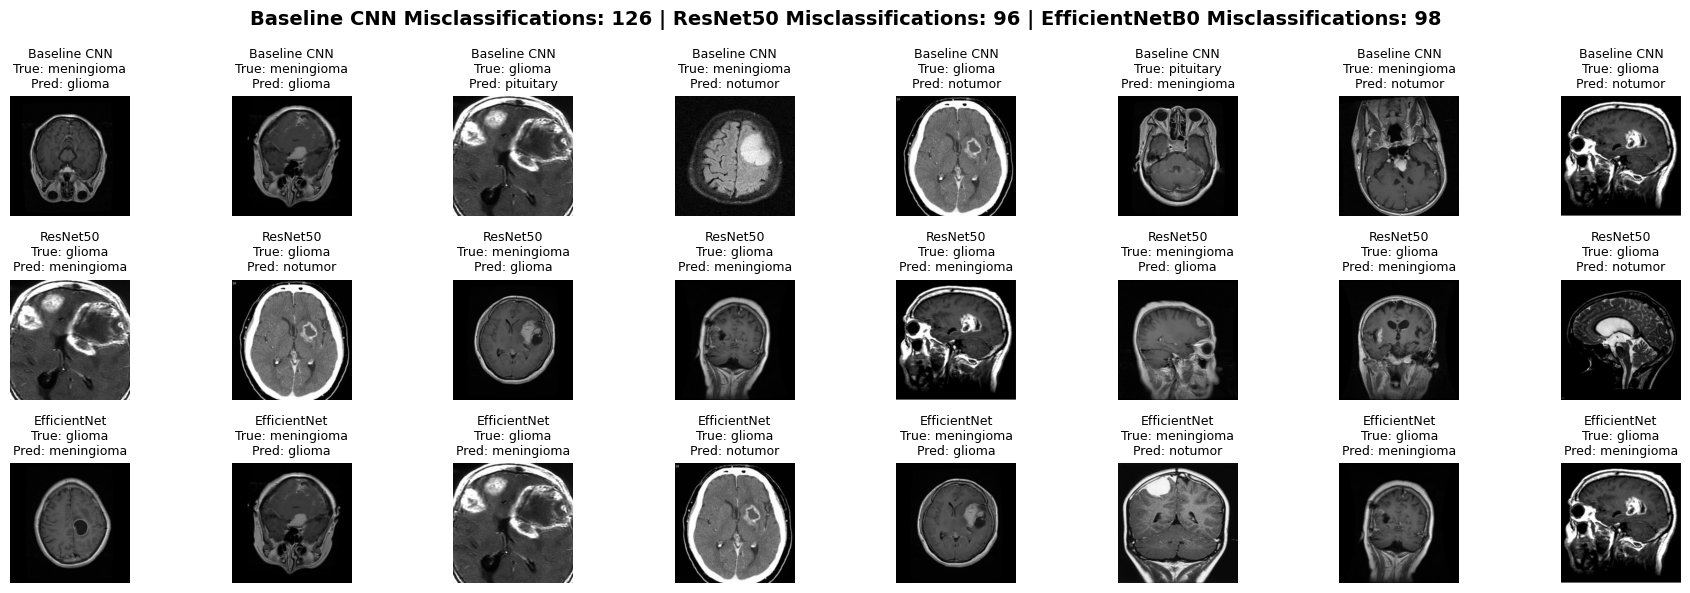

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Class names
class_names = list(test_gen.class_indices.keys())


# Get predictions for all three models

# Baseline CNN
baseline_pred_probs = model.predict(test_gen)
baseline_pred_labels = np.argmax(baseline_pred_probs, axis=1)
baseline_true_labels = test_gen.classes

# ResNet50
resnet_pred_probs = resnet_model.predict(resnet_test_gen)
resnet_pred_labels = np.argmax(resnet_pred_probs, axis=1)
resnet_true_labels = resnet_test_gen.classes

# EfficientNetB0
eff_pred_probs = eff_model.predict(eff_test_gen)
eff_pred_labels = np.argmax(eff_pred_probs, axis=1)
eff_true_labels = eff_test_gen.classes


# Find misclassifications for each model
baseline_misclass = np.where(baseline_pred_labels != baseline_true_labels)[0]
resnet_misclass = np.where(resnet_pred_labels != resnet_true_labels)[0]
eff_misclass = np.where(eff_pred_labels != eff_true_labels)[0]


# Display misclassifications for all three models
num_samples = 8
rows = 3
cols = num_samples

plt.figure(figsize=(18, 6))

for i, idx in enumerate(baseline_misclass[:num_samples]):
    file_path = test_df.iloc[idx]["File Path"]
    true_label = class_names[baseline_true_labels[idx]]
    pred_label = class_names[baseline_pred_labels[idx]]

    img = Image.open(file_path).convert("L")
    img = img.resize((224, 224))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Baseline CNN\nTrue: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")


for i, idx in enumerate(resnet_misclass[:num_samples]):
    file_path = test_df.iloc[idx]["File Path"]
    true_label = class_names[resnet_true_labels[idx]]
    pred_label = class_names[resnet_pred_labels[idx]]

    img = Image.open(file_path).convert("L")
    img = img.resize((224, 224))

    plt.subplot(rows, cols, i + cols + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"ResNet50\nTrue: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")


for i, idx in enumerate(eff_misclass[:num_samples]):
    file_path = test_df.iloc[idx]["File Path"]
    true_label = class_names[eff_true_labels[idx]]
    pred_label = class_names[eff_pred_labels[idx]]

    img = Image.open(file_path).convert("L")
    img = img.resize((224, 224))

    plt.subplot(rows, cols, i + 2*cols + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"EfficientNet\nTrue: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")


plt.suptitle(
    f"Baseline CNN Misclassifications: {len(baseline_misclass)} | "
    f"ResNet50 Misclassifications: {len(resnet_misclass)} | "
    f"EfficientNetB0 Misclassifications: {len(eff_misclass)}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

code to implement and visualize the Precision vs Recall analysis

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
Baseline metrics:
         Class  Precision  Recall  F1-score
0      glioma      0.855   0.680     0.758
1  meningioma      0.764   0.795     0.779
2     notumor      0.835   0.965     0.896
3   pituitary      0.921   0.930     0.925

ResNet50 metrics:
         Class  Precision  Recall  F1-score
0      glioma      0.964   0.670     0.791
1  meningioma      0.730   0.935     0.820
2     notumor      0.916   0.985     0.949
3   pituitary      0.979   0.930     0.954

EfficientNet metrics:
         Class  Precision  Recall  F1-score
0      glioma      0.924   0.665     0.773
1  meningioma      0.778   0.860     0.817
2     notumor      0.877   0.995     0.932
3   pituitary      0.952   0.990     0.971

False Negatives per class (critical):

Baseline:
  glioma: 64
  meningioma: 41
  notumor: 7
  pituitary: 14

ResNet50:
  glioma: 66
  meningioma: 13
  notumor: 3
  p

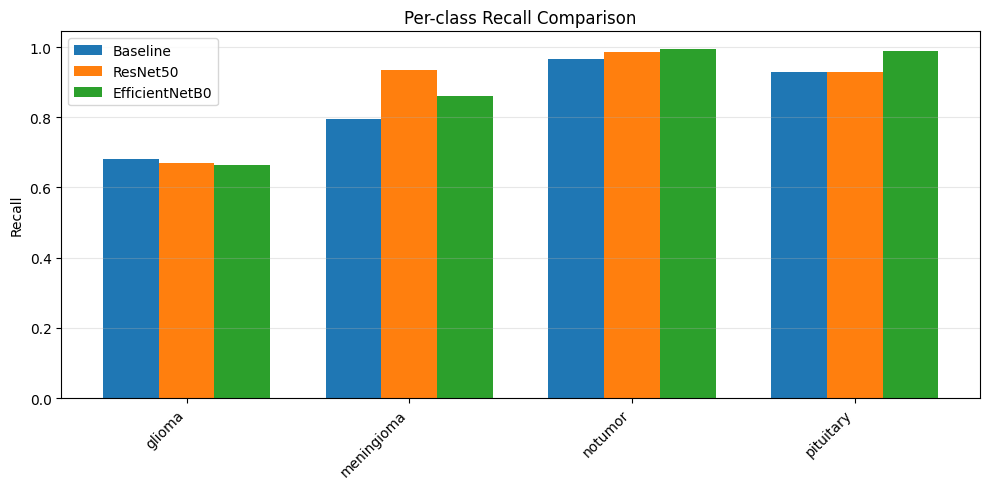

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# --- helper to check name in globals ---
def exists(name):
    return name in globals()

# --- ensure test_gen exists (you already created it) ---
if not exists("test_gen"):
    raise RuntimeError("test_gen not found. Create generators before running this cell.")

# class names from the baseline test generator
class_names = list(test_gen.class_indices.keys())
n_classes = len(class_names)

# --- get predictions with fallbacks ---
# Baseline CNN (model)
if exists("model"):
    baseline_probs = model.predict(test_gen)
    baseline_preds = np.argmax(baseline_probs, axis=1)
    baseline_true = test_gen.classes
else:
    raise RuntimeError("Baseline model 'model' not found in session.")

# ResNet50
if exists("resnet_model"):
    if exists("resnet_test_gen"):
        resnet_tgen = resnet_test_gen
    else:
        # fallback to using shared test_gen (ensure preprocessing matches)
        resnet_tgen = test_gen
    resnet_probs = resnet_model.predict(resnet_tgen)
    resnet_preds = np.argmax(resnet_probs, axis=1)
    resnet_true = resnet_tgen.classes
else:
    raise RuntimeError("ResNet model 'resnet_model' not found in session.")

# EfficientNetB0
if exists("eff_model"):
    if exists("eff_test_gen"):
        eff_tgen = eff_test_gen
    else:
        eff_tgen = test_gen
    eff_probs = eff_model.predict(eff_tgen)
    eff_preds = np.argmax(eff_probs, axis=1)
    eff_true = eff_tgen.classes
else:
    raise RuntimeError("EfficientNet model 'eff_model' not found in session.")


# --- align class spaces (sanity) ---
# If any generator uses different class indices ordering, map labels to baseline ordering.
def map_labels_to_baseline(gen):
    # gen.class_indices: {class_name: idx_in_that_generator}
    if gen.class_indices == test_gen.class_indices:
        return None  # same mapping
    # build mapping from generator idx -> baseline idx
    mapping = {}
    for cname, idx in gen.class_indices.items():
        baseline_idx = test_gen.class_indices.get(cname)
        if baseline_idx is None:
            raise RuntimeError(f"Class {cname} not found in baseline test_gen.")
        mapping[idx] = baseline_idx
    return mapping

# Map resnet_true/preds if needed
if exists("resnet_tgen") and resnet_tgen is not test_gen:
    map_res = map_labels_to_baseline(resnet_tgen)
    if map_res is not None:
        resnet_true = np.array([map_res[int(x)] for x in resnet_true])
        resnet_preds = np.array([map_res[int(x)] for x in resnet_preds])

# Map eff_true/preds if needed
if exists("eff_tgen") and eff_tgen is not test_gen:
    map_eff = map_labels_to_baseline(eff_tgen)
    if map_eff is not None:
        eff_true = np.array([map_eff[int(x)] for x in eff_true])
        eff_preds = np.array([map_eff[int(x)] for x in eff_preds])


# --- compute per-class metrics safely (handle classes with no samples) ---
def per_class_metrics(true, pred, n_cls):
    # If a class has zero true samples, sklearn precision/recall returns ill-defined warnings.
    # We'll compute and replace undefined with 0.0
    prec = precision_score(true, pred, labels=list(range(n_cls)), average=None, zero_division=0)
    rec = recall_score(true, pred, labels=list(range(n_cls)), average=None, zero_division=0)
    f1 = f1_score(true, pred, labels=list(range(n_cls)), average=None, zero_division=0)
    return prec, rec, f1

baseline_prec, baseline_rec, baseline_f1 = per_class_metrics(baseline_true, baseline_preds, n_classes)
resnet_prec, resnet_rec, resnet_f1 = per_class_metrics(resnet_true, resnet_preds, n_classes)
eff_prec, eff_rec, eff_f1 = per_class_metrics(eff_true, eff_preds, n_classes)

# Build DataFrames
baseline_metrics = pd.DataFrame({"Class": class_names, "Precision": baseline_prec, "Recall": baseline_rec, "F1-score": baseline_f1})
resnet_metrics   = pd.DataFrame({"Class": class_names, "Precision": resnet_prec,    "Recall": resnet_rec,    "F1-score": resnet_f1})
eff_metrics      = pd.DataFrame({"Class": class_names, "Precision": eff_prec,       "Recall": eff_rec,       "F1-score": eff_f1})

print("Baseline metrics:\n", baseline_metrics.round(3))
print("\nResNet50 metrics:\n", resnet_metrics.round(3))
print("\nEfficientNet metrics:\n", eff_metrics.round(3))


# False negatives per class
print("\nFalse Negatives per class (critical):")
for name, true, pred in [("Baseline", baseline_true, baseline_preds),
                         ("ResNet50", resnet_true, resnet_preds),
                         ("EffNetB0", eff_true, eff_preds)]:
    cm = confusion_matrix(true, pred, labels=list(range(n_classes)))
    fn = cm.sum(axis=1) - np.diag(cm)
    print(f"\n{name}:")
    for cname, val in zip(class_names, fn):
        print(f"  {cname}: {val}")


# Plot recall comparison (side-by-side)
x = np.arange(n_classes)
width = 0.25
plt.figure(figsize=(10,5))
plt.bar(x - width, baseline_metrics["Recall"], width, label="Baseline")
plt.bar(x, resnet_metrics["Recall"], width, label="ResNet50")
plt.bar(x + width, eff_metrics["Recall"], width, label="EfficientNetB0")
plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Recall")
plt.title("Per-class Recall Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Evaluate on training

 EVALUATION AND TRAINING CURVES



Training set evaluation:
350/350 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9657 - loss: 0.1118

Validation set evaluation:
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8450 - loss: 0.7310

Test set evaluation:
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8425 - loss: 0.7359


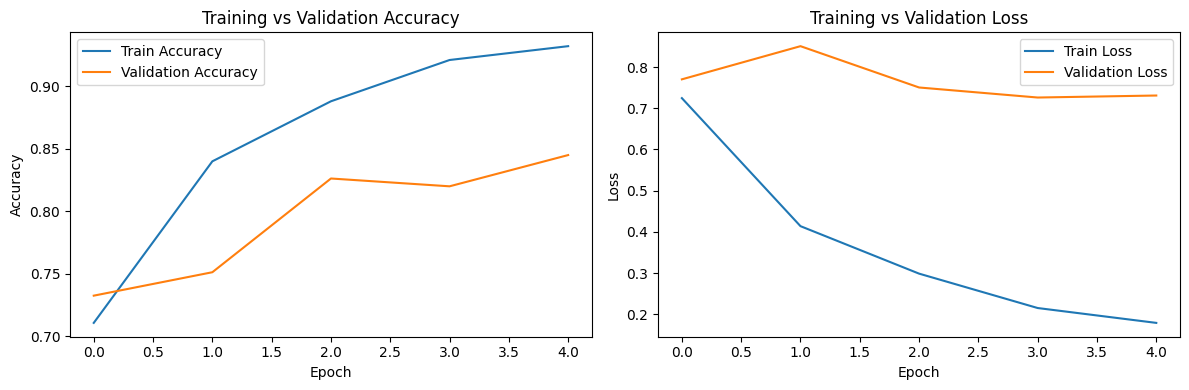

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.86      0.68      0.76       200
  meningioma       0.76      0.80      0.78       200
     notumor       0.84      0.96      0.90       200
   pituitary       0.92      0.93      0.93       200

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



<Figure size 600x600 with 0 Axes>

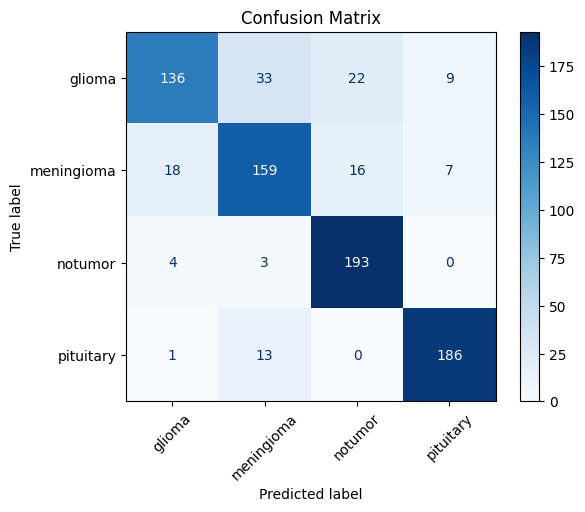

In [35]:
# ---------------------------
# Evaluate on training, validation, and test sets
# ---------------------------
print("\nTraining set evaluation:")
train_results = model.evaluate(train_gen, verbose=1)

print("\nValidation set evaluation:")
valid_results = model.evaluate(valid_gen, verbose=1)

print("\nTest set evaluation:")
test_results = model.evaluate(test_gen, verbose=1)

# ---------------------------
# Plot training history
# ---------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------
# Predictions on test set
# ---------------------------
pred_probs = model.predict(test_gen)
pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------
# Classification report
# ---------------------------
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

# ---------------------------
# Confusion matrix
# ---------------------------
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

 DATA AUGMENTATION


In [ ]:
# ---------------------------
# ImageDataGenerator with augmentation
# ---------------------------
aug_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

aug_train_gen = aug_train_datagen.flow_from_dataframe(
    train_df,
    x_col="File Path",
    y_col="Label",
    target_size=image_size,
    class_mode="categorical",
    color_mode="rgb",
    batch_size=train_batch_size,
    shuffle=True
)

# ---------------------------
# Train augmented model
# ---------------------------
aug_model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(32, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(16, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])

aug_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

aug_history = aug_model.fit(
    aug_train_gen,
    validation_data=valid_gen,
    epochs=5,
    verbose=1
)

print("\nAugmented model test evaluation:")
aug_model.evaluate(test_gen, verbose=1)

# ---------------------------
# Compare baseline vs augmentation
# ---------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["val_accuracy"], label="Baseline Validation Accuracy")
plt.plot(aug_history.history["val_accuracy"], label="Augmented Validation Accuracy")
plt.title("Baseline vs Augmented Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["val_loss"], label="Baseline Validation Loss")
plt.plot(aug_history.history["val_loss"], label="Augmented Validation Loss")
plt.title("Baseline vs Augmented Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# OPTIONAL - SAVE MODEL
# ============================================================

# Uncomment if you want to save a model
# model.save("/content/drive/MyDrive/brain_tumor_baseline_model.h5")
# improved_model.save("/content/drive/MyDrive/brain_tumor_improved_model.h5")
# aug_model.save("/content/drive/MyDrive/brain_tumor_augmented_model.h5")

print("\nEnd of template.")

Found 5600 validated image filenames belonging to 4 classes.
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 85s 230ms/step - accuracy: 0.5863 - loss: 0.9413 - val_accuracy: 0.6800 - val_loss: 1.0084
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 141s 233ms/step - accuracy: 0.7362 - loss: 0.6761 - val_accuracy: 0.7275 - val_loss: 0.8862
Epoch 3/5
334/350 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.7613 - loss: 0.6058

##End of code -------------------------------------------------------------------------